# PLN — Aula 7: Embeddings de Palavras (aplicado a Tweets de Times de Futebol)

Neste notebook, exploramos **representações vetoriais densas de palavras** (*word embeddings*) aplicadas a um dataset real: **tweets em português sobre 12 times de futebol brasileiros** (`tweets_tratados_final.csv`).

Comparamos duas abordagens clássicas de embeddings **estáticos** — onde cada palavra tem um único vetor fixo, independente do contexto:

1. **Word2Vec** (Mikolov et al., 2013) — treinado **do zero** sobre o nosso corpus de tweets, aprendendo um vocabulário específico do domínio (futebol brasileiro, com gírias, nomes de jogadores, hashtags etc.).
2. **spaCy (`pt_core_news_lg`)** — vetores **pré-treinados** em corpora gerais de português (Wikipédia, notícias), usados como referência genérica.

A pergunta central:

> **Os embeddings de palavras conseguem agrupar tweets pelo time mencionado, mesmo sem nenhum treinamento supervisionado?**

#### Base conceitual (revisão da aula)

> *"You shall know a word by the company it keeps."* — Firth

A **hipótese distribucional** sustenta que palavras que ocorrem em contextos semelhantes tendem a ter significados semelhantes. Word2Vec aprende isso a partir de janelas de coocorrência (CBOW prevê a palavra-alvo a partir do contexto; Skip-gram faz o inverso). O resultado é um espaço vetorial denso onde **proximidade ≈ similaridade semântica**.

---

## Instruções de Uso

- **Execute as células em ordem**, de cima para baixo.
- Após a primeira célula de instalação, o Colab pode pedir **reiniciar o runtime**. Se acontecer, vá em **Runtime → Reiniciar sessão** e execute tudo novamente.
- Você precisa do arquivo `tweets_tratados_final.csv`. No Colab, faça o upload quando o widget aparecer; localmente, basta deixá-lo na mesma pasta do notebook.


# Parte 1 — Word2Vec treinado no corpus de tweets

Word2Vec (Mikolov et al., 2013) introduziu duas arquiteturas simples de rede neural para gerar embeddings: **CBOW** (Continuous Bag-of-Words) e **Skip-Gram**. Em ambas, a ideia é aproveitar **janelas de contexto** em torno das palavras: o modelo aprende que palavras que ocorrem em contextos similares têm significados similares.

- **CBOW**: dada uma janela de palavras de contexto, prevê a palavra central.
- **Skip-Gram**: dada a palavra central, prevê as palavras de contexto.

Aqui usaremos **CBOW** (`sg=0`), padrão para corpora pequenos e médios.


In [ ]:
# Instalação/atualização das dependências
# Garante gensim atualizado (>=4.4.0), compatível com NumPy 2.x do Colab
!pip install --upgrade gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings("ignore")

# Tokenizador do NLTK
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)  # fallback p/ versões antigas

SEED = 42
np.random.seed(SEED)

## Carregando o Dataset

O arquivo `tweets_tratados_final.csv` contém **1.299 tweets** em português, já com tratamento básico (URLs removidas, normalização etc.), distribuídos entre **12 times** de futebol brasileiros:

| Coluna | Descrição |
|---|---|
| `Time` | Time associado ao tweet — 12 valores possíveis (Flamengo, Santos, Corinthians, Grêmio, Vasco, Cruzeiro, Palmeiras, São Paulo, Botafogo, Internacional, Fluminense, Atlético Mineiro). |
| `Nome` | Nome de exibição do usuário. |
| `Usuario` | Handle (`@...`). |
| `Texto` | **O texto do tweet** — é o que vamos vetorizar. |
| `Data` | Data e hora. |
| `topicos` | Hashtags extraídas (pode ser `NaN`). |
| `Stop words` | Stopwords detectadas. |

Se você está no **Google Colab**, o bloco abaixo abre um upload widget. Se estiver rodando localmente, basta deixar o CSV na mesma pasta do notebook.


In [ ]:
# --- Carregamento robusto: tenta upload no Colab, senão busca local ---
CSV_NAME = "tweets_tratados_final.csv"

if not os.path.exists(CSV_NAME):
    try:
        from google.colab import files  # type: ignore
        print("Faça o upload do arquivo 'tweets_tratados_final.csv'...")
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname != CSV_NAME:
                os.rename(fname, CSV_NAME)
    except ImportError:
        raise FileNotFoundError(
            f"Arquivo '{CSV_NAME}' não encontrado. "
            "Coloque-o na mesma pasta do notebook ou rode no Colab para fazer upload."
        )

df = pd.read_csv(CSV_NAME)
print(f"Linhas: {len(df)}  |  Colunas: {list(df.columns)}")
df.head()

Linhas: 1299  |  Colunas: ['Time', 'Nome', 'Usuario', 'Texto', 'Data', 'topicos', 'Stop words']


,Time,Nome,Usuario,Texto,Data,topicos,Stop words
0,Fluminense,guimarãess,@guimaffc,"merece fluminense fudido 2019, 2009, 2017, 201...",2026-03-19 19:03:32,NaN,"tu, o, de"
1,Flamengo,𐙚 jessi • arirang,@yoonbg7,"flamengo 20h comeback arirang 01hr, army flame...",2026-03-19 19:03:30,NaN,"e, tá"
2,Flamengo,CFD - Futebol e Fantasies,@CFD_Oficial,": rossi; emerson royal, léo ortiz, léo pereira...",2026-03-19 19:03:30,"Flamengo, Remo","e, e, e, e, de, e, e"
3,Flamengo,DECO SRN,@Deco_SRN,flamengo remo escalados!,2026-03-19 19:03:27,NaN,e
4,Flamengo,Deivede,@Deivede73,indo ver flamengo remo porque nunca vou saber ...,2026-03-19 19:03:24,NaN,"e, eu, um, do, de, e, por, que, o, do, é, e, p..."


In [ ]:
# Distribuição dos tweets por time
print("Tweets por time:")
print(df["Time"].value_counts())
print(f"\nTotal de times: {df['Time'].nunique()}")

Tweets por time:
Time
Flamengo            414
Santos              230
Corinthians          97
Grêmio               95
Vasco                92
São Paulo            81
Palmeiras            75
Botafogo             60
Cruzeiro             59
Fluminense           55
Internacional        36
Atlético Mineiro      5
Name: count, dtype: int64

Total de times: 12


## Pré-processamento: Tokenização dos Tweets

Word2Vec opera sobre **listas de tokens**, então precisamos transformar cada tweet em uma sequência de palavras.

Tweets têm peculiaridades em relação ao conjunto de exemplos da aula original:

- Caracteres não-alfabéticos espalhados (pontuação, emojis residuais).
- Mistura de **maiúsculas** (gritos: "VAMOS FLAMENGO!").
- **Hashtags** já estavam separadas no campo `topicos`, então no `Texto` aparecem só palavras "comuns".
- **Stopwords**: o pré-processamento original já as registrou em uma coluna separada, mas elas continuam no `Texto`. Para Word2Vec **não removemos stopwords** — elas dão contexto e ajudam o modelo a aprender melhor (diferente de TF-IDF).

A função `tokenizar` abaixo:

1. Coloca em **minúsculas**.
2. Remove caracteres que não sejam letras (incluindo acentuadas), dígitos ou espaços.
3. Aplica `word_tokenize` do NLTK.
4. Filtra tokens com 1 caractere (geralmente lixo).


In [ ]:
# Decide se podemos usar word_tokenize do NLTK (depende do download do punkt_tab).
# Se o download falhou, caímos em uma tokenização baseada em regex — quase tão boa para tweets.
try:
    word_tokenize("teste de tokenização")
    USAR_NLTK = True
except LookupError:
    USAR_NLTK = False
    print("Aviso: NLTK punkt_tab indisponível, usando tokenizador por regex como fallback.")

def tokenizar(texto: str) -> list:
    """Tokenização leve: lowercase + remoção de símbolos + tokens de comprimento >= 2."""
    if not isinstance(texto, str):
        return []
    t = texto.lower()
    # Mantém letras (incluindo acentuadas), dígitos e espaços
    t = re.sub(r"[^a-záàâãéèêíïóôõöúçñ0-9\s]", " ", t)
    tokens = word_tokenize(t) if USAR_NLTK else t.split()
    return [tok for tok in tokens if len(tok) > 1]

# Aplica tokenização a todos os tweets
df["tokens"] = df["Texto"].apply(tokenizar)

# Diagnóstico
n_tokens_total = df["tokens"].apply(len).sum()
vocab_aprox = len(set(t for toks in df["tokens"] for t in toks))
print(f"Total de tokens no corpus: {n_tokens_total}")
print(f"Vocabulário (tipos únicos):    {vocab_aprox}")
print(f"Tokens médios por tweet:       {df['tokens'].apply(len).mean():.1f}")
print(f"\nExemplo de tokenização:")
print(f"  Texto : {df['Texto'].iloc[0][:120]}")
print(f"  Tokens: {df['tokens'].iloc[0]}")

Total de tokens no corpus: 16512
Vocabulário (tipos únicos):    4607
Tokens médios por tweet:       12.7

Exemplo de tokenização:
  Texto : merece fluminense fudido 2019, 2009, 2017, 2018, 2024
  Tokens: ['merece', 'fluminense', 'fudido', '2019', '2009', '2017', '2018', '2024']


## Treinamento do Modelo Word2Vec

Treinamos um Word2Vec sobre **todos os 1.299 tweets** (já tokenizados em `df["tokens"]`).

**Parâmetros escolhidos:**

| Parâmetro | Valor | Por quê |
|---|---|---|
| `vector_size` | 100 | Dimensão dos vetores. 100 é um bom equilíbrio entre expressividade e custo para um corpus pequeno. |
| `window` | 5 | Janela de contexto (5 palavras de cada lado). |
| `min_count` | 2 | Ignora palavras que aparecem só 1 vez — em corpus pequeno, hapax legomena fazem ruído. |
| `workers` | 4 | Threads paralelas. |
| `sg` | 0 | **CBOW**, padrão para corpora pequenos (Skip-gram precisa de mais dados). |
| `epochs` | 30 | Mais que o default (5) — em corpus pequeno como o nosso, mais épocas ajudam os vetores a se diferenciarem. |

> **Atenção:** com apenas ~1.300 tweets curtos, este Word2Vec é "de brinquedo" comparado a modelos pré-treinados. Mas é exatamente esse o ponto pedagógico: ver o que dá para aprender com **dados próprios** vs. modelos pré-treinados (spaCy, Parte 2).


In [ ]:
# Hiperparâmetros
vector_dim     = 100
window_size    = 5
min_word_count = 2
num_workers    = 4
n_epochs       = 30

# Treinamento Word2Vec (CBOW)
model_w2v = Word2Vec(
    sentences=df["tokens"].tolist(),
    vector_size=vector_dim,
    window=window_size,
    min_count=min_word_count,
    workers=num_workers,
    sg=0,                  # CBOW
    epochs=n_epochs,
    seed=SEED,
)

print(f"Modelo treinado.")
print(f"  Vocabulário final: {len(model_w2v.wv.index_to_key)} palavras")
print(f"  Dimensão dos vetores: {model_w2v.wv.vector_size}")

Modelo treinado.
  Vocabulário final: 1765 palavras
  Dimensão dos vetores: 100


## Inspeção do modelo: as palavras vizinhas fazem sentido?

Antes de usar os vetores em tarefas de larga escala, vale fazer um **sanity check** clássico do Word2Vec: para uma palavra, quais são as suas vizinhas mais próximas no espaço vetorial? Se o modelo aprendeu bem, palavras semanticamente relacionadas (no contexto deste corpus) devem aparecer no topo.

Se você ver coisas como:
- `gol` → `golaço`, `marcar`, `bola`...
- `flamengo` → `mengão`, `rubro`, `fla`...
- `arbitragem` → `juiz`, `var`, `roubo`...

...então o modelo capturou estrutura. Se as vizinhas parecerem aleatórias, o corpus é pequeno demais (esperável aqui — vimos que o vocabulário é de poucos milhares de palavras).


In [ ]:
# Palavras-sonda: pessoais ou específicas de futebol
sondas = ["gol", "flamengo", "santos", "neymar", "arbitragem", "torcida", "jogador", "técnico"]

for palavra in sondas:
    if palavra in model_w2v.wv:
        vizinhas = model_w2v.wv.most_similar(palavra, topn=5)
        formatadas = ", ".join(f"{w} ({s:.2f})" for w, s in vizinhas)
        print(f"  {palavra:12s} → {formatadas}")
    else:
        print(f"  {palavra:12s} → (fora do vocabulário)")

  gol          → tomar (0.99), vai (0.99), jogo (0.99), maracanã (0.99), remo (0.99)
  flamengo     → pro (0.99), minutos (0.99), maracanã (0.99), enfrentar (0.99), tomando (0.99)
  santos       → vinicius (0.97), douglas (0.97), seleção (0.97), andrey (0.97), condições (0.97)
  neymar       → seleção (0.99), brasileira (0.99), vinícius (0.99), merecem (0.99), reserva (0.99)
  arbitragem   → vocês (1.00), abel (1.00), semana (1.00), direito (1.00), 2025 (1.00)
  torcida      → perdeu (1.00), maracanã (1.00), dar (1.00), música (1.00), vitórias (1.00)
  jogador      → fraco (1.00), pior (1.00), horrível (1.00), horroroso (1.00), lateral (1.00)
  técnico      → próprio (1.00), outra (1.00), presidente (1.00), estava (1.00), rio (1.00)


## Vetor de Documento = Média dos Vetores das Palavras

Word2Vec dá um vetor por **palavra**. Para representar um **tweet inteiro** com um único vetor, a estratégia mais simples é a **média** dos vetores das palavras que aparecem no tweet (e que estão no vocabulário do modelo).

Isso tem limitações conhecidas:
- Perde a ordem das palavras.
- Tweets com palavras muito comuns ("e", "de", "o") tendem a um centróide neutro.
- Mas é rápido, simples e suficiente para começar.

Mais tarde, na **Aula 8 (BERT)**, veremos uma alternativa: usar diretamente embeddings contextuais por sentença, que respeitam a ordem.


In [ ]:
def vetor_medio(tokens, model):
    """Retorna a média dos vetores das palavras presentes no vocabulário do modelo."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vecs, axis=0)

# Vetor por tweet
vetores_tweets = np.array([vetor_medio(toks, model_w2v) for toks in df["tokens"]])

# Quantos tweets ficaram zerados (nenhum token reconhecido)?
zerados = int((vetores_tweets.sum(axis=1) == 0).sum())
print(f"vetores_tweets.shape = {vetores_tweets.shape}")
print(f"Tweets com vetor zerado (descartáveis): {zerados}")

vetores_tweets.shape = (1299, 100)
Tweets com vetor zerado (descartáveis): 1


## Similaridade de Cosseno entre Tweets — Heatmap

A **similaridade de cosseno** mede o cosseno do ângulo entre dois vetores: `1` significa direção idêntica (semanticamente próximos), `0` significa ortogonais (sem relação), valores negativos significam oposição.

> ⚠️ **Adaptação para o dataset:** o exemplo original tinha 11 documentos → heatmap 11×11 perfeitamente legível. Aqui temos 1.299 tweets → 1.299×1.299 ≈ 1,7 milhão de células, ilegível.  
> Solução: para o heatmap, sorteamos uma **sub-amostra estratificada** com 2 tweets por time (24 tweets, heatmap 24×24).


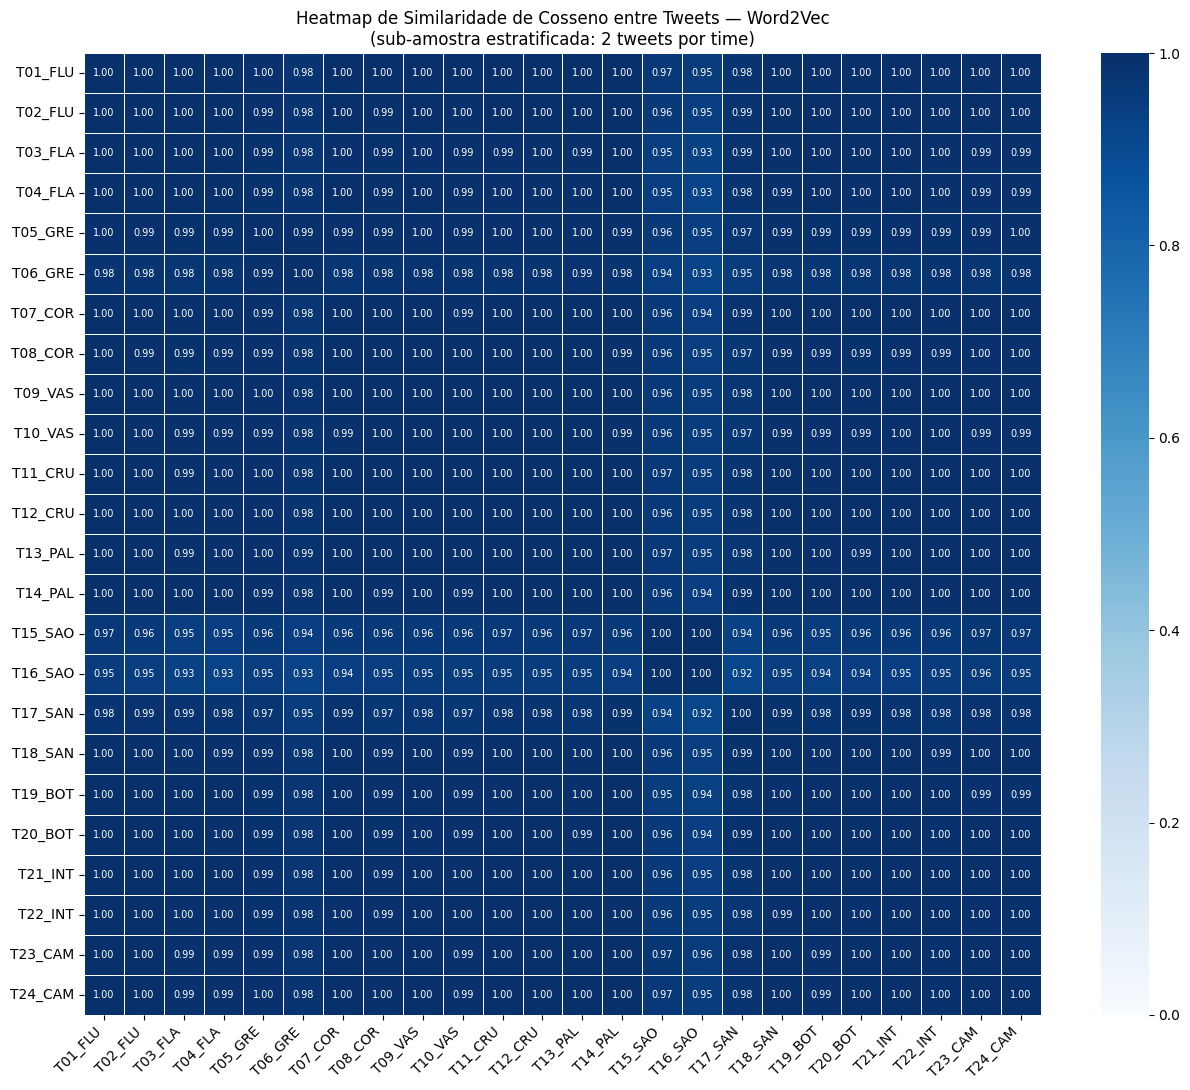


Legenda dos rótulos:
  T01_FLU  [Fluminense        ] ainda há outra questão acho importante relação jogos entre fluminense vasco: fato justiça rj ter lav
  T02_FLU  [Fluminense        ] preparados possível mudança data paraná x nacional seria domingo dia 05/04? nessa mesma data coritib
  T03_FLA  [Flamengo          ] trazer luíz henrique independente valor. ou meio ano, ou final pra começar temporada 27 já aqui. aci
  T04_FLA  [Flamengo          ] tentei entrar 3 links flamengo nenhum existe.
  T05_GRE  [Grêmio            ] camisa grêmio fosse tricolor até as mangas ia perfeita
  T06_GRE  [Grêmio            ] começa jogo! grêmio x vitória transmissão ao vivo: …
  T07_COR  [Corinthians       ] corinthians joga mais bonito
  T08_COR  [Corinthians       ] admirar torcida corinthians fez!!!
  T09_VAS  [Vasco             ] iludidao já né? kkkkkkkkk famoso embalinho anual vasco fode cabeça torcida
  T10_VAS  [Vasco             ] argumentos? vasco ganhou ano passado?
  T11_CRU  [Cruzeiro    

In [ ]:
# Sub-amostra estratificada: 2 tweets por time
def amostra_por_grupo(df, col_grupo, n_por_grupo, random_state):
    partes = []
    for _, sub in df.groupby(col_grupo, sort=False):
        n = min(len(sub), n_por_grupo)
        partes.append(sub.sample(n=n, random_state=random_state))
    return pd.concat(partes)

df_hm = amostra_por_grupo(df, "Time", n_por_grupo=2, random_state=SEED)
idx_hm = df_hm.index.tolist()

# Vetores e rótulos da sub-amostra
vec_hm   = vetores_tweets[idx_hm]
times_hm = df_hm["Time"].tolist()
text_hm  = df_hm["Texto"].tolist()

# Rótulos curtos para os eixos (T01_FLA, T02_SAN, ...)
abrev_time = {
    "Flamengo": "FLA", "Santos": "SAN", "Corinthians": "COR", "Grêmio": "GRE",
    "Vasco": "VAS", "Cruzeiro": "CRU", "Palmeiras": "PAL", "São Paulo": "SAO",
    "Botafogo": "BOT", "Internacional": "INT", "Fluminense": "FLU", "Atlético Mineiro": "CAM",
}
labels_hm = [f"T{i+1:02d}_{abrev_time.get(t, t[:3].upper())}" for i, t in enumerate(times_hm)]

# Matriz de similaridade
matriz_sim = cosine_similarity(vec_hm)

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 11))
sns.heatmap(
    matriz_sim, annot=True, cmap="Blues", fmt=".2f",
    linewidths=.4,
    xticklabels=labels_hm, yticklabels=labels_hm,
    annot_kws={"size": 7},
    vmin=0, vmax=1,
)
plt.title("Heatmap de Similaridade de Cosseno entre Tweets — Word2Vec\n"
          "(sub-amostra estratificada: 2 tweets por time)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Para inspeção, mostra a quais tweets correspondem os rótulos
print("\nLegenda dos rótulos:")
for lbl, t, txt in zip(labels_hm, times_hm, text_hm):
    print(f"  {lbl}  [{t:18s}] {txt[:100]}")

## Busca semântica de tweets

Aplicação clássica de embeddings: dado um termo de busca, retornar os tweets mais **semanticamente próximos** — não apenas os que contêm exatamente as mesmas palavras.

A função abaixo:
1. Tokeniza a consulta com a mesma função usada para o corpus.
2. Calcula o vetor médio da consulta no espaço Word2Vec.
3. Calcula similaridade de cosseno entre a consulta e todos os 1.299 tweets.
4. Retorna os top-K mais similares com seu time real.

> No notebook original, a consulta vinha por `input()` — interativo, mas trava em ambientes não-interativos. Aqui usamos uma variável `consulta` fixa que você pode editar. Se preferir o modo interativo, descomente a linha `input(...)`.


In [ ]:
def recomendar_tweets_w2v(consulta, model, df_corpus, vetores_corpus, top_k=10):
    """Retorna os top_k tweets mais similares à consulta, segundo Word2Vec."""
    tokens_busca = tokenizar(consulta)
    if not tokens_busca:
        print("Consulta vazia.")
        return pd.DataFrame()

    vetores_consulta = [model.wv[t] for t in tokens_busca if t in model.wv]
    if not vetores_consulta:
        print(f"Nenhuma palavra de '{consulta}' está no vocabulário do modelo.")
        return pd.DataFrame()

    vetor_consulta = np.mean(vetores_consulta, axis=0).reshape(1, -1)
    sims = cosine_similarity(vetor_consulta, vetores_corpus)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    return pd.DataFrame({
        "Similaridade": sims[top_idx].round(3),
        "Time":         df_corpus["Time"].iloc[top_idx].values,
        "Texto":        df_corpus["Texto"].iloc[top_idx].values,
    })

# === Edite a consulta abaixo (ou descomente o input para modo interativo) ===
consulta = "gol da vitória"
# consulta = input("Digite os termos de busca: ")

print(f"Consulta: '{consulta}'\n")
recomendacoes = recomendar_tweets_w2v(consulta, model_w2v, df, vetores_tweets, top_k=10)
recomendacoes

Consulta: 'gol da vitória'



,Similaridade,Time,Texto
0,0.997,Grêmio,começa jogo! grêmio 0x0 vitória
1,0.997,Grêmio,"recomeça jogo. vamos, grêmio! 1x0 vitória"
2,0.997,Grêmio,silêncio começou grêmio x vitória vai tomar c ...
3,0.997,Grêmio,começa jogo! grêmio x vitória transmissão ao v...
4,0.996,Grêmio,começou segundo tempo: grêmio 1x0 vitória
5,0.996,Grêmio,brasileirão - 7ª rodada: bola rolando grêmio 0...
6,0.996,Grêmio,aquele link grêmio x vitória cade????
7,0.996,Grêmio,bola rolando arena: grêmio x vitória
8,0.996,Grêmio,bola rolando! grêmio x vitória
9,0.995,Grêmio,começou brasileirão série 2026 7º rodada grêmi...


## Clusterização com K-Means

Aplicamos **K-Means** diretamente sobre os vetores Word2Vec dos tweets. A pergunta é se o algoritmo, sem ver os rótulos, vai redescobrir os times.

**Decisão de design:** usamos `k=12`, exatamente o número de times. Isso permite:

- Comparar cada cluster com a distribuição real de times via **Adjusted Rand Index** (ARI).
- Avaliar a qualidade intrínseca dos clusters via **silhouette score** (que não usa rótulos reais).


In [ ]:
N_CLUSTERS = 12  # = nº de times

# Filtra tweets que tenham pelo menos algum vetor não-zero
mask_validos = vetores_tweets.sum(axis=1) != 0
X_valid    = vetores_tweets[mask_validos]
df_valid   = df[mask_validos].reset_index(drop=True)
times_real = df_valid["Time"].values

print(f"Tweets usados para clusterização: {len(X_valid)} (descartados {len(df)-len(X_valid)} com vetor zerado)")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
clusters_w2v = kmeans.fit_predict(X_valid)

df_valid = df_valid.copy()
df_valid["cluster_w2v"] = clusters_w2v

# Métricas
sil = silhouette_score(X_valid, clusters_w2v)
ari = adjusted_rand_score(times_real, clusters_w2v)

print(f"\nSilhouette score (intrínseco): {sil:.4f}")
print(f"Adjusted Rand Index vs Time:   {ari:.4f}")
print("  - silhouette: -1 a 1 (maior = clusters mais bem separados)")
print("  - ARI:        ~0 (aleatório) a 1 (perfeito); negativo = pior que o acaso")

Tweets usados para clusterização: 1298 (descartados 1 com vetor zerado)

Silhouette score (intrínseco): 0.2413
Adjusted Rand Index vs Time:   0.0831
  - silhouette: -1 a 1 (maior = clusters mais bem separados)
  - ARI:        ~0 (aleatório) a 1 (perfeito); negativo = pior que o acaso


### Cross-tab: cluster × time real

A tabela cruzada mostra, **para cada cluster**, quantos tweets de cada time caíram nele.  
Idealmente cada cluster concentraria tweets de poucos times (e cada time se concentraria em poucos clusters).


In [ ]:
ct = pd.crosstab(df_valid["Time"], df_valid["cluster_w2v"])
print("Cross-tab (linhas = time real, colunas = cluster do K-Means):")
ct

Cross-tab (linhas = time real, colunas = cluster do K-Means):


cluster_w2v,0,1,2,3,4,5,6,7,8,9,10,11
Time,,,,,,,,,,,,
Atlético Mineiro,0,0,2,0,0,0,3,0,0,0,0,0
Botafogo,0,4,17,0,16,0,13,8,1,1,0,0
Corinthians,1,17,40,0,13,1,18,4,0,3,0,0
Cruzeiro,0,9,13,0,10,0,21,2,0,1,2,1
Flamengo,2,49,121,2,46,0,140,14,17,18,3,1
Fluminense,0,5,20,0,7,0,16,4,1,1,1,0
Grêmio,0,4,21,0,10,0,25,2,0,0,2,31
Internacional,0,5,16,0,5,0,8,2,0,0,0,0
Palmeiras,7,3,24,0,4,0,32,3,1,1,0,0


In [ ]:
# Para cada cluster, qual time é majoritário e qual é a "pureza"?
print("Composição de cada cluster (top time + pureza %):\n")
for c in sorted(df_valid["cluster_w2v"].unique()):
    sub = df_valid[df_valid["cluster_w2v"] == c]
    top_time = sub["Time"].value_counts().idxmax()
    pureza = sub["Time"].value_counts().max() / len(sub) * 100
    print(f"  Cluster {c:2d}  |  n={len(sub):4d}  |  time dominante: {top_time:18s} (pureza: {pureza:5.1f}%)")

Composição de cada cluster (top time + pureza %):

  Cluster  0  |  n=  67  |  time dominante: São Paulo          (pureza:  85.1%)
  Cluster  1  |  n= 105  |  time dominante: Flamengo           (pureza:  46.7%)
  Cluster  2  |  n= 337  |  time dominante: Flamengo           (pureza:  35.9%)
  Cluster  3  |  n=  21  |  time dominante: Santos             (pureza:  85.7%)
  Cluster  4  |  n= 139  |  time dominante: Flamengo           (pureza:  33.1%)
  Cluster  5  |  n=  12  |  time dominante: São Paulo          (pureza:  91.7%)
  Cluster  6  |  n= 318  |  time dominante: Flamengo           (pureza:  44.0%)
  Cluster  7  |  n= 112  |  time dominante: Santos             (pureza:  58.9%)
  Cluster  8  |  n=  23  |  time dominante: Flamengo           (pureza:  73.9%)
  Cluster  9  |  n=  80  |  time dominante: Santos             (pureza:  65.0%)
  Cluster 10  |  n=  51  |  time dominante: Santos             (pureza:  82.4%)
  Cluster 11  |  n=  33  |  time dominante: Grêmio             (purez

## Visualização 3D com PCA

Reduzimos os vetores Word2Vec (100 dimensões) para **3 componentes principais** e plotamos com Plotly. Cada ponto é um tweet.

Geramos **dois gráficos**:

1. **Colorido por cluster do K-Means** — versão do notebook original, mas agora com 1.299 tweets em vez de 11.
2. **Colorido pelo time real** — a comparação mais informativa: se enxergamos blocos de cor coerentes no espaço, os embeddings capturaram sinal de identidade de time.


In [ ]:
import plotly.express as px

# PCA 3D
pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X_valid)
expl_var = pca.explained_variance_ratio_
print(f"Variância explicada por componente: {expl_var.round(3)}")
print(f"Total nos 3 PCs: {expl_var.sum():.1%}")

# DataFrame para o Plotly
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["Cluster"]   = df_valid["cluster_w2v"].astype(str).values
pca_df["Time"]      = df_valid["Time"].values
pca_df["Texto"]     = df_valid["Texto"].apply(lambda s: s if len(s) <= 120 else s[:120] + "...").values

Variância explicada por componente: [0.403 0.316 0.162]
Total nos 3 PCs: 88.1%


In [ ]:
# --- Gráfico 1: colorido por CLUSTER ---
fig_cluster = px.scatter_3d(
    pca_df, x="PC1", y="PC2", z="PC3",
    color="Cluster",
    title=f"Tweets em 3D (Word2Vec + PCA) — colorido por cluster K-Means (k={N_CLUSTERS})",
    hover_data={"Texto": True, "Time": True, "Cluster": True,
                "PC1": ":.2f", "PC2": ":.2f", "PC3": ":.2f"},
    width=950, height=700,
)
fig_cluster.update_traces(marker=dict(size=3, opacity=0.75))
fig_cluster.show()

In [ ]:
# --- Gráfico 2: colorido por TIME REAL ---
# Paleta com 12 cores distintas
palette = px.colors.qualitative.Light24[:12]

fig_time = px.scatter_3d(
    pca_df, x="PC1", y="PC2", z="PC3",
    color="Time",
    color_discrete_sequence=palette,
    title="Tweets em 3D (Word2Vec + PCA) — colorido por TIME REAL",
    hover_data={"Texto": True, "Time": True, "Cluster": True,
                "PC1": ":.2f", "PC2": ":.2f", "PC3": ":.2f"},
    width=950, height=700,
)
fig_time.update_traces(marker=dict(size=3, opacity=0.75))
fig_time.show()

# Parte 2 — Vetores Pré-treinados com spaCy

Word2Vec acima foi treinado **do zero** sobre nossos 1.299 tweets — corpus pequeno, vocabulário restrito, embeddings de qualidade limitada.

A alternativa é usar embeddings **pré-treinados** em corpora grandes. O spaCy distribui um modelo de português, **`pt_core_news_lg`**, que inclui vetores treinados em corpora extensos (Wikipédia, notícias). A sigla "lg" (*large*) indica que ele inclui esses vetores; as versões "sm" e "md" não incluem ou incluem menos.

> **O contraste pedagógico:**  
> Word2Vec do nosso corpus = **embeddings específicos do domínio** (aprende gírias de torcida, mas pouco do resto).  
> spaCy pré-treinado = **embeddings genéricos de português** (não viu nada específico de futebol, mas tem cobertura lexical ampla).


In [ ]:
# Instala o modelo grande de português do spaCy (com vetores)
import spacy
!python -m spacy download pt_core_news_lg --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 2.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Carrega o modelo (pode demorar ~30s na primeira vez)
nlp = spacy.load("pt_core_news_lg")

# Sanity check — exemplos clássicos
doc = nlp("O gato está dormindo no sofá.")
gato_tok = doc[1]
sofa_tok = doc[-2]
print(f"Dimensão do vetor em spaCy: {len(gato_tok.vector)}")
print(f"Similaridade entre 'gato' e 'sofá': {gato_tok.similarity(sofa_tok):.3f}")

palavra1 = nlp("felino")[0]
palavra2 = nlp("gato")[0]
print(f"Similaridade entre 'felino' e 'gato': {palavra1.similarity(palavra2):.3f}")

# E para o nosso domínio?
print()
for w1, w2 in [("flamengo", "vasco"), ("flamengo", "futebol"), ("gol", "vitória"),
               ("torcida", "estádio"), ("juiz", "arbitragem")]:
    s = nlp(w1)[0].similarity(nlp(w2)[0])
    print(f"  '{w1}' ~ '{w2}':  {s:.3f}")

Dimensão do vetor em spaCy: 300
Similaridade entre 'gato' e 'sofá': 0.403
Similaridade entre 'felino' e 'gato': 0.696

  'flamengo' ~ 'vasco':  0.726
  'flamengo' ~ 'futebol':  0.516
  'gol' ~ 'vitória':  0.450
  'torcida' ~ 'estádio':  0.467
  'juiz' ~ 'arbitragem':  0.425


## Aplicando spaCy aos tweets

O `Doc` do spaCy tem uma propriedade `.vector` que é a **média dos vetores dos tokens** — exatamente a mesma estratégia que usamos no Word2Vec, mas agora com vetores **pré-treinados** de 300 dimensões.

> Este passo demora alguns minutos no Colab (CPU) porque o spaCy roda o pipeline completo (tokenizer + POS + parser + NER) em cada tweet. Para acelerar, **desativamos os componentes que não usamos** — só queremos os vetores.


In [ ]:
# Pipeline mais leve (só tokenizer; ignora POS/parser/NER porque só queremos vetores)
disable_pipes = [p for p in nlp.pipe_names if p != "tok2vec"]
print(f"Desativando: {disable_pipes}")

textos = df["Texto"].astype(str).tolist()
vetores_spacy = []

# nlp.pipe é mais eficiente que loop com nlp(t) para cada um
with nlp.select_pipes(disable=disable_pipes):
    for doc in nlp.pipe(textos, batch_size=64):
        vetores_spacy.append(doc.vector)

vetores_spacy = np.array(vetores_spacy)
print(f"\nvetores_spacy.shape = {vetores_spacy.shape}")
print(f"Dimensão dos vetores: {vetores_spacy.shape[1]}")

Desativando: ['morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']

vetores_spacy.shape = (1299, 300)
Dimensão dos vetores: 300


## Comparando: Word2Vec próprio vs spaCy pré-treinado

Repetimos clusterização e métricas com os vetores do spaCy. A pergunta concreta:

> **Vetores genéricos (spaCy) ou vetores específicos do domínio (Word2Vec próprio) agrupam melhor os tweets pelo time?**

Esperamos que:
- spaCy tenha **maior pureza lexical geral** (300 dimensões, treinado em milhões de tokens).
- Word2Vec próprio capture melhor **gírias de torcida** específicas, mas seu corpus minúsculo limita a generalização.


In [ ]:
# Filtra spaCy para os mesmos tweets válidos do Word2Vec (consistência)
mask_spacy_valid = vetores_spacy.sum(axis=1) != 0
print(f"Tweets com vetor spaCy não-zero: {mask_spacy_valid.sum()} de {len(df)}")

# Para comparação justa, usamos a interseção dos dois conjuntos válidos
mask_join = mask_validos & mask_spacy_valid
X_w2v_j   = vetores_tweets[mask_join]
X_spacy_j = vetores_spacy[mask_join]
times_j   = df.loc[mask_join, "Time"].values

print(f"Tweets na interseção (Word2Vec ∩ spaCy): {mask_join.sum()}\n")

resultados = []
for nome, X in [("Word2Vec (treinado nos tweets)", X_w2v_j),
                ("spaCy pt_core_news_lg (pré-treinado)", X_spacy_j)]:
    km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    ari = adjusted_rand_score(times_j, labels)
    resultados.append({
        "Modelo": nome,
        "Dim": X.shape[1],
        "Silhouette": round(sil, 4),
        "ARI vs Time": round(ari, 4),
    })

pd.DataFrame(resultados)

Tweets com vetor spaCy não-zero: 1298 de 1299
Tweets na interseção (Word2Vec ∩ spaCy): 1298



,Modelo,Dim,Silhouette,ARI vs Time
0,Word2Vec (treinado nos tweets),100,0.2413,0.0831
1,spaCy pt_core_news_lg (pré-treinado),300,0.0325,0.0103


### PCA dos embeddings spaCy — colorido por time

Mesmo gráfico de antes (PCA 3D), mas com os **vetores spaCy** e colorido pelo time real. Compare visualmente com o gráfico equivalente do Word2Vec acima: as nuvens de cor estão mais "puxadas" pelos times no spaCy?


In [ ]:
# PCA dos embeddings spaCy
pca_sp = PCA(n_components=3, random_state=SEED)
X_pca_sp = pca_sp.fit_transform(X_spacy_j)
print(f"Variância explicada (spaCy 3 PCs): {pca_sp.explained_variance_ratio_.sum():.1%}")

# DataFrame
df_pca_sp = pd.DataFrame(X_pca_sp, columns=["PC1", "PC2", "PC3"])
df_pca_sp["Time"]  = times_j
df_pca_sp["Texto"] = df.loc[mask_join, "Texto"].apply(
    lambda s: s if len(s) <= 120 else s[:120] + "..."
).values

fig_sp = px.scatter_3d(
    df_pca_sp, x="PC1", y="PC2", z="PC3",
    color="Time",
    color_discrete_sequence=palette,
    title="Tweets em 3D (spaCy pt_core_news_lg + PCA) — colorido por TIME REAL",
    hover_data={"Texto": True, "Time": True,
                "PC1": ":.2f", "PC2": ":.2f", "PC3": ":.2f"},
    width=950, height=700,
)
fig_sp.update_traces(marker=dict(size=3, opacity=0.75))
fig_sp.show()

Variância explicada (spaCy 3 PCs): 32.6%


## Conclusão

Adaptamos o pipeline de **embeddings estáticos** (Word2Vec + spaCy) da aula original para um cenário realista: 1.299 tweets em português sobre 12 times de futebol.

#### O que olhar nos resultados

- **Sondagem de palavras vizinhas** (`most_similar`): o Word2Vec próprio capturou estrutura mesmo com corpus pequeno?
- **Heatmap em sub-amostra**: tweets do mesmo time tendem a ficar com similaridade alta entre si (mas atenção: pares do mesmo time podem ainda ficar baixos se falam de eventos diferentes)?
- **Tabela comparativa Word2Vec × spaCy**: qual deu maior **ARI vs Time**? E maior **silhouette**? Os dois critérios podem discordar.
- **Cross-tab e pureza por cluster**: existem times que se concentram em poucos clusters? Outros que se espalham?
- **Scatter 3D colorido por time**: dá pra enxergar manchas coerentes? Em qual dos dois (Word2Vec ou spaCy) elas são mais nítidas?

#### Limitações dos embeddings estáticos (o que vem na próxima aula)

Tudo aqui é **estático**: cada palavra tem um vetor fixo. Isso significa que:

- **"banco"** em "banco de dados" e "banco do parque" tem o mesmo vetor — perde-se o contexto.
- A média de vetores por documento perde a **ordem das palavras**. "Flamengo venceu o Vasco" e "Vasco venceu o Flamengo" têm o mesmo vetor de documento.

A **Aula 8 (BERT)** resolve isso com embeddings **contextuais**: cada ocorrência de uma palavra ganha um vetor diferente conforme o contexto da sentença. Veremos isso aplicado a este mesmo dataset de tweets.

#### Sugestões de exploração

- Variar `vector_size` (50, 200, 300) e `epochs` (10, 30, 50) e ver o que muda no ARI.
- Trocar `sg=0` (CBOW) por `sg=1` (Skip-gram) — Skip-gram costuma ir melhor em palavras raras.
- Filtrar stopwords antes de calcular o vetor médio do documento — pode ajudar ou atrapalhar, depende do corpus.
- Substituir K-Means por **HDBSCAN** (density-based) — costuma achar clusters mais naturais em embeddings de texto.
- Combinar o vetor Word2Vec do tweet com features de TF-IDF (tem teoria que dão sinais complementares).
